In [185]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import calendar
import seaborn as sns
import os
import matplotlib.ticker as plticker

In [234]:
proc_data_folder = "proc_data"
filename_stem = "np_merged" # all_cases p_merged np_merged

if filename_stem[0] == "a":
    category = "Total"
elif filename_stem[0] == "p":
    category = "Poisonous"
else:
    category = "Non-poisonous"

case_df = gpd.read_file(os.path.join(proc_data_folder, filename_stem + "_districts.geojson"))
pop_df = pd.read_csv(os.path.join(proc_data_folder, "pop_dist.csv"), dtype={"district_code": str})

info_cols = [col for col in case_df.columns if "20" not in col]

In [235]:
# --- Configuration ---
YEARS = np.linspace(2018, 2025, 8, dtype = int)

SEASON_MONTHS = {
    'Spring': [3, 4, 5],
    'Summer': [6, 7, 8],
    'Autumn': [9, 10, 11],
    'Winter': [12, 1, 2],
}

In [236]:
YEARS

array([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])

In [237]:
pop_df['district_code'] = pop_df['district_code'].astype(str).str.strip()
case_df['organisationunitcode'] = case_df['organisationunitcode'].astype(str).str.strip()

In [238]:
# --- Parse case count date columns ---
case_date_cols = {}  # Timestamp -> col_name
for col in case_df.columns:
    try:
        ts = pd.Timestamp(col)
        case_date_cols[ts] = col
    except Exception:
        continue

def get_season_case_cols(year, months):
    cols = []
    for month in months:
        y = year + 1 if month in [1, 2] else year
        for ts, col in case_date_cols.items():
            if ts.year == y and ts.month == month:
                cols.append(col)
    return cols

def get_pop_col(year):
    pop_target = pd.Timestamp(f"{year}-12-31")
    pop_date_cols = []
    for col in pop_df.columns:
        if col == 'district_code':
            continue
        try:
            pop_date_cols.append(pd.Timestamp(col))
        except Exception:
            continue
    closest = min(pop_date_cols, key=lambda d: abs(d - pop_target))
    return closest.strftime('%Y-%m-%d %H:%M:%S')

In [239]:
# --- Merge on district ---
merged = case_df.merge(
    pop_df, left_on='organisationunitcode', right_on='district_code', how='inner'
)

In [240]:
k = pd.melt(merged[["DISTRICT", "geometry", "elev_mean"] + [col for col in merged.columns if '31' in col]],
        id_vars=["DISTRICT", "geometry", "elev_mean"],
        value_vars=[col for col in merged.columns if '31' in col],
        var_name="year",
        value_name="pop")
k = k.drop(columns=["year"]).groupby(["DISTRICT", "geometry"], as_index=False).mean()
k = gpd.GeoDataFrame(k, geometry='geometry', crs="EPSG:4326")

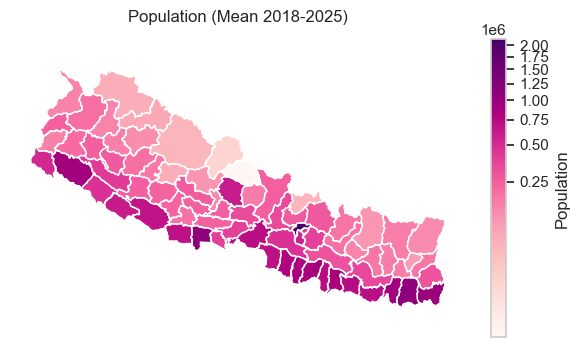

In [241]:
ax = k.plot(
    column="pop",
    cmap="RdPu",
    legend=True,
    legend_kwds={"label": "Population", "orientation": "vertical", "fraction": 0.03},
    norm=mcolors.PowerNorm(gamma=0.3)
)
ax.set_title("Population (Mean 2018-2025)", pad=25)
ax.set_axis_off()

plt.savefig(os.path.join("figures", 'pop_map.png'), dpi=150, bbox_inches='tight')

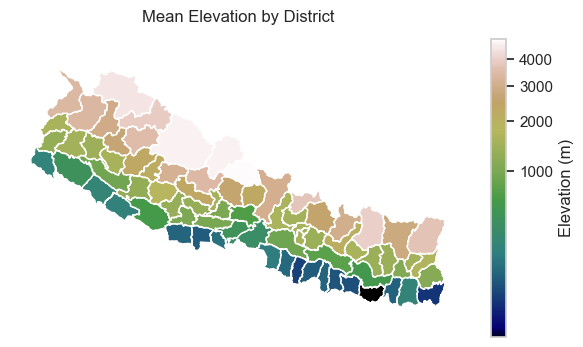

In [242]:
ax = k.plot(
    column="elev_mean",
    cmap="gist_earth",
    legend=True,
    legend_kwds={"label": "Elevation (m)", "orientation": "vertical", "fraction": 0.03},
    norm=mcolors.PowerNorm(gamma=0.35)
)
ax.set_title("Mean Elevation by District", pad=25)
ax.set_axis_off()

plt.savefig(os.path.join("figures", 'elev_map.png'), dpi=150, bbox_inches='tight')

In [243]:
# --- Build rate columns ---
rate_cols = {}
for year in YEARS:
    pop_col = get_pop_col(year)
    for season, months in SEASON_MONTHS.items():
        col_names = [f"{year}_{season}_rate", f"{year}_{season}_count"]
        case_cols = get_season_case_cols(year, months)

        def compute_rate(row, case_cols=case_cols, pop_col=pop_col):
            pop = pd.to_numeric(row.get(pop_col), errors='coerce')
            if pd.isna(pop) or pop == 0:
                return np.nan
            cases = sum(pd.to_numeric(row.get(c, np.nan), errors='coerce') for c in case_cols)
            return (cases / pop) * 100_000

        def compute_count(row, case_cols=case_cols):
            count = sum(pd.to_numeric(row.get(c, np.nan), errors='coerce') for c in case_cols)
            return count

        rate_cols[col_names[0]] = merged.apply(compute_rate, axis=1)
        rate_cols[col_names[1]] = merged.apply(compute_count, axis=1)

# --- Assemble final dataframe ---
result_df = merged[info_cols].copy()
for col_name, values in rate_cols.items():
    result_df[col_name] = values

In [244]:
YEARS_subset = [YEARS[i] for i in [0,3,7]]
YEARS_subset

[np.int64(2018), np.int64(2021), np.int64(2025)]

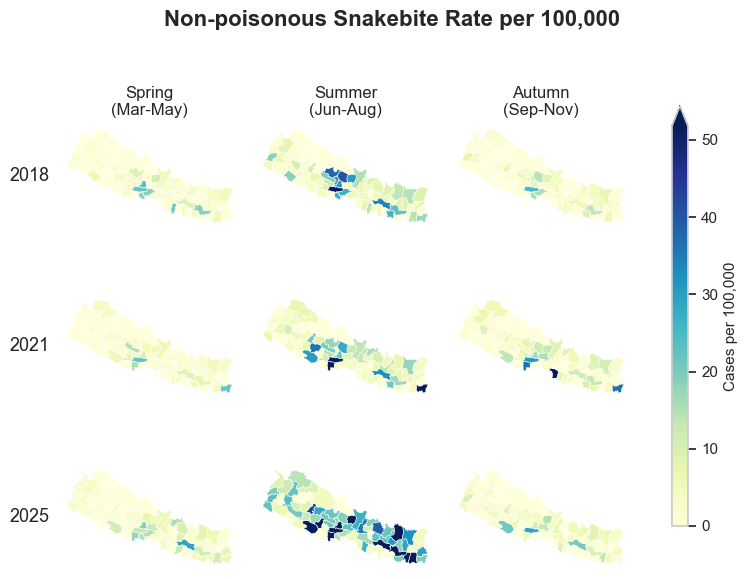

In [245]:
cmap = 'YlGnBu'
SEASONS = list(SEASON_MONTHS.keys())[:3]

# --- Shared color scale across all subplots ---
rate_cols = [f"{y}_{s}_rate" for y in YEARS_subset for s in SEASONS]
vmin = np.nanpercentile(result_df[rate_cols].values, 5)   # robust min
vmax = np.nanpercentile(result_df[rate_cols].values, 98)  # robust max

# --- Plot ---
fig, axes = plt.subplots(len(YEARS_subset), len(SEASONS), figsize=(8,6))
fig.suptitle(category + ' Snakebite Rate per 100,000', fontsize=16, fontweight='bold', y=1.01)

for i, year in enumerate(YEARS_subset):
    for j, season in enumerate(SEASONS):
        ax = axes[i][j]
        col = f"{year}_{season}_rate"

        result_df.plot(
            column=col,
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            edgecolor='white',
            linewidth=0.3
        )

        if j == 0:
            ax.annotate(str(year), xy=(-0.05, 0.5), xycoords='axes fraction',
                        fontsize=13, va='center', ha='right', rotation=0)
        
        ax.axis('off')

for ax, col in zip(axes[0], SEASONS):
    label = col + "\n" + f"({calendar.month_abbr[SEASON_MONTHS[col][0]]}-{calendar.month_abbr[SEASON_MONTHS[col][2]]})" 
    ax.set_title(label)

# --- Shared colorbar ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])

plt.tight_layout()
plt.subplots_adjust(hspace=0.05, right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax, extend='max')
cbar.set_label('Cases per 100,000', fontsize=11)

plt.savefig(os.path.join("figures", category.lower() + '_seasonal_rates_map.png'), dpi=150, bbox_inches='tight')
plt.show()

In [246]:
col_sub = ["DISTRICT", "elev_mean", "elev_max"] + [col for col in result_df.columns if 'Summer_rate' in col]
col_sub

['DISTRICT',
 'elev_mean',
 'elev_max',
 '2018_Summer_rate',
 '2019_Summer_rate',
 '2020_Summer_rate',
 '2021_Summer_rate',
 '2022_Summer_rate',
 '2023_Summer_rate',
 '2024_Summer_rate',
 '2025_Summer_rate']

In [247]:
hm = result_df[col_sub].sort_values(by='elev_mean').set_index('DISTRICT')
hm.tail(5)

vmin = np.nanpercentile(hm[[col for col in result_df.columns if 'Summer_rate' in col]].values, 5)   # robust min
vmax = np.nanpercentile(result_df[[col for col in result_df.columns if 'Summer_rate' in col]].values, 98)  # robust max

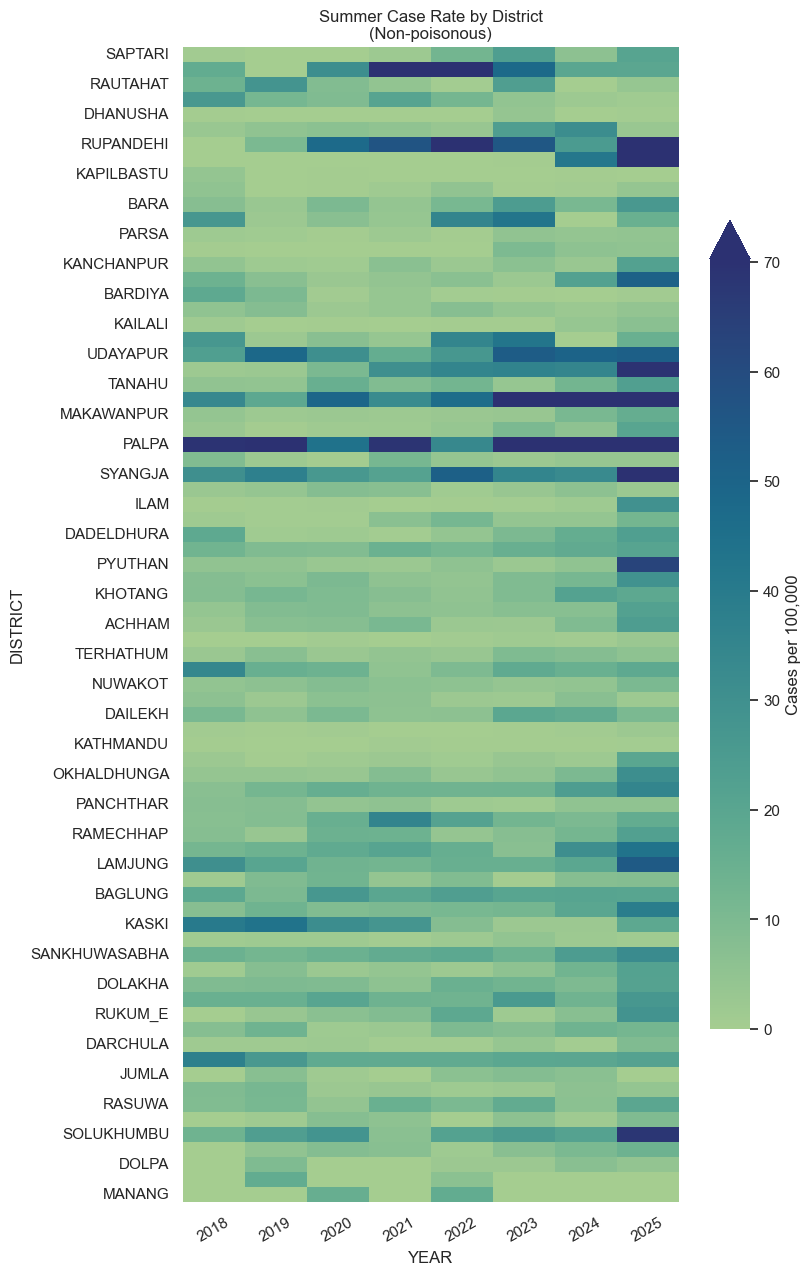

In [248]:
plt.figure(figsize=(8, 15))
ax = sns.heatmap(hm.drop(columns=["elev_mean", "elev_max"]), cmap="crest", 
                 vmax = vmax, cbar_kws={'orientation': 'vertical', 'shrink': 0.7, 'label': 'Cases per 100,000', 'extend': 'max'})
ax.set(xlabel="YEAR")
ax.set_xticklabels(YEARS, rotation=30)
ax.set_title(f"Summer Case Rate by District\n({category})")

plt.savefig(os.path.join("figures", category.lower() + '_summer_by_district.png'),
            dpi=150, 
            bbox_inches='tight')

In [249]:
tc = merged[[col for col in merged.columns if ('20' in col)]].sum().to_frame().T

rates = {}
for year in YEARS:
    pop_col = get_pop_col(year)
    for season, months in SEASON_MONTHS.items():
        col_name = f"{year}_{season}_rate"
        case_cols = get_season_case_cols(year, months)

        def compute_rate(row, case_cols=case_cols, pop_col=pop_col):
            pop = pd.to_numeric(row.get(pop_col), errors='coerce')
            if pd.isna(pop) or pop == 0:
                return np.nan
            cases = sum(pd.to_numeric(row.get(c, np.nan), errors='coerce') for c in case_cols)
            return (cases / pop) * 100_000

        rates[col_name] = tc.apply(compute_rate, axis=1)

# --- Assemble final dataframe ---
all_nepal_result_df = pd.DataFrame()
for col_name, values in rates.items():
    all_nepal_result_df[col_name] = values

all_nepal_result_df["DISTRICT"] = "ALL_NEPAL"

In [250]:
matched_cols = ["DISTRICT"] + [col for col in all_nepal_result_df.columns if ('Summer' in col)]
summary_rate_df = all_nepal_result_df[matched_cols]
summary_rate_df

,DISTRICT,2018_Summer_rate,2019_Summer_rate,2020_Summer_rate,2021_Summer_rate,2022_Summer_rate,2023_Summer_rate,2024_Summer_rate,2025_Summer_rate
0,ALL_NEPAL,8.717842,7.359279,9.042506,13.703013,13.393232,14.169834,12.27669,23.122689


In [251]:
cols_all_rates = ["DISTRICT", "elev_mean"] + [col for col in result_df.columns if ('Summer_rate' in col)]
dist_rates_long = result_df[cols_all_rates]

ranges = {}
dist_rates_long['Quartile'] = pd.qcut(dist_rates_long['elev_mean'], q=4, labels=[1, 2, 3, 4])
for i, (e_min, e_max) in enumerate(zip(
    dist_rates_long.groupby(["Quartile"]).min().elev_mean,
    dist_rates_long.groupby(["Quartile"]).max().elev_mean)):
    ranges[i+1] = (int(e_min), int(e_max))
dist_rates_long = dist_rates_long.drop(columns=["elev_mean"])
# df_ts = pd.concat([dist_rates_long, summary_rate_df])
dist_rates_long

,DISTRICT,2018_Summer_rate,2019_Summer_rate,2020_Summer_rate,2021_Summer_rate,2022_Summer_rate,2023_Summer_rate,2024_Summer_rate,2025_Summer_rate,Quartile
0,DOTI,6.086969,2.341537,6.557715,6.297138,2.366707,2.003978,7.013923,2.003978,3
1,RAMECHHAP,7.690903,3.356558,14.351526,14.072615,4.112132,7.417526,11.931376,22.606817,3
2,DANG,2.052092,2.637446,10.674621,30.385139,35.185874,36.114068,34.939626,69.732448,2
3,RUPANDEHI,0.096422,10.576614,47.635300,56.589414,85.494418,55.376744,25.218517,72.102427,1
4,SINDHULI,33.661206,18.685206,49.386200,32.272768,46.247816,74.394290,73.414484,117.395511,2
...,...,...,...,...,...,...,...,...,...,...
72,DHADING,7.109483,11.883407,16.047207,13.627438,13.283700,13.562957,24.226864,35.239075,3
73,TAPLEJUNG,9.202807,11.481144,2.292001,3.323198,1.660371,2.627269,6.130295,4.378782,4
74,BANKE,0.509962,0.166147,0.000000,0.165217,0.000000,10.015281,5.976861,5.330714,1
75,PALPA,69.400958,70.718232,44.125267,69.087470,33.974948,70.533548,78.606665,141.067096,2


In [252]:
x = pd.melt(dist_rates_long,
        id_vars=["DISTRICT", "Quartile"],
        value_vars=[col for col in dist_rates_long.columns if ('20' in col)],
        var_name="timeframe",
        value_name="rate")
x.tail(3)

,DISTRICT,Quartile,timeframe,rate
613,BANKE,1,2025_Summer_rate,5.330714
614,PALPA,2,2025_Summer_rate,141.067096
615,RUKUM_E,4,2025_Summer_rate,28.570408


In [253]:
y = pd.melt(summary_rate_df,
        id_vars=["DISTRICT"],
        value_vars=[col for col in summary_rate_df.columns if ('20' in col)],
        var_name="timeframe",
        value_name="rate")
y

,DISTRICT,timeframe,rate
0,ALL_NEPAL,2018_Summer_rate,8.717842
1,ALL_NEPAL,2019_Summer_rate,7.359279
2,ALL_NEPAL,2020_Summer_rate,9.042506
3,ALL_NEPAL,2021_Summer_rate,13.703013
4,ALL_NEPAL,2022_Summer_rate,13.393232
5,ALL_NEPAL,2023_Summer_rate,14.169834
6,ALL_NEPAL,2024_Summer_rate,12.276690
7,ALL_NEPAL,2025_Summer_rate,23.122689


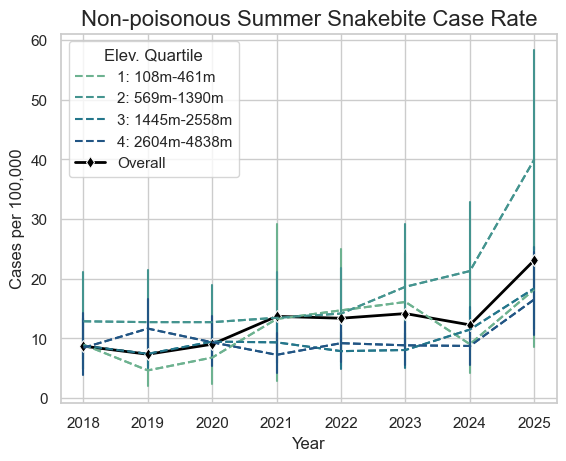

In [254]:
sns.set_theme(style="whitegrid")
r_fmt = "{i}: {e_min}m-{e_max}m"
leg_labs = [r_fmt.format(i = i+1, e_min = r[0], e_max = r[1]) for i, r in enumerate(ranges.values())]
leg_labs.append("Overall")
pal = "crest"

fig, ax = plt.subplots()

sns.lineplot(
    data=x, x="timeframe", y="rate", hue="Quartile",
    palette = pal,
    err_style="bars"
)

ax.lines[0].set_linestyle("--")
    
## Using collections
# plt.setp(ax.collections, alpha=0.15)
plt.setp(ax.lines, linestyle="dashed")

sns.lineplot(data= y, color ="black", x="timeframe", y="rate", lw=2, marker="d", label='Overall')

plt.xticks(np.arange(8), YEARS)
plt.title(category + ' Summer Snakebite Case Rate', fontsize=16)
plt.xlabel("Year")
plt.ylabel("Cases per 100,000")

# Get the handles and labels
handles, labels = ax.get_legend_handles_labels()

# Pass the original handles and the new labels to legend()
ax.legend(handles, leg_labs, loc='best', title="Elev. Quartile")

plt.savefig(os.path.join("figures", category.lower() + '_summer_by_elev_quartile.png'),
            dpi=150, 
            bbox_inches='tight')
plt.show()

In [255]:
count_cols = ["DISTRICT", "elev_mean", "elev_max"] + [col for col in result_df.columns if 'Summer_count' in col]
count_cols

['DISTRICT',
 'elev_mean',
 'elev_max',
 '2018_Summer_count',
 '2019_Summer_count',
 '2020_Summer_count',
 '2021_Summer_count',
 '2022_Summer_count',
 '2023_Summer_count',
 '2024_Summer_count',
 '2025_Summer_count']

In [256]:
hm = result_df[count_cols].sort_values(by='elev_mean')
q = 4
hm['elev_quantile'] = pd.qcut(hm['elev_mean'], q=q, labels=np.arange(start=1,stop=q+1))
z = pd.melt(hm,
        id_vars=["DISTRICT", "elev_mean", "elev_quantile"],
        value_vars=[col for col in hm.columns if ('20' in col)],
        var_name="year",
        value_name="cases")

z['year'] = z['year'].str.slice(0, 4)
z.head(3)

,DISTRICT,elev_mean,elev_quantile,year,cases
0,SAPTARI,108.901974,1,2018,6.0
1,JHAPA,119.776135,1,2018,156.0
2,RAUTAHAT,126.545681,1,2018,116.0


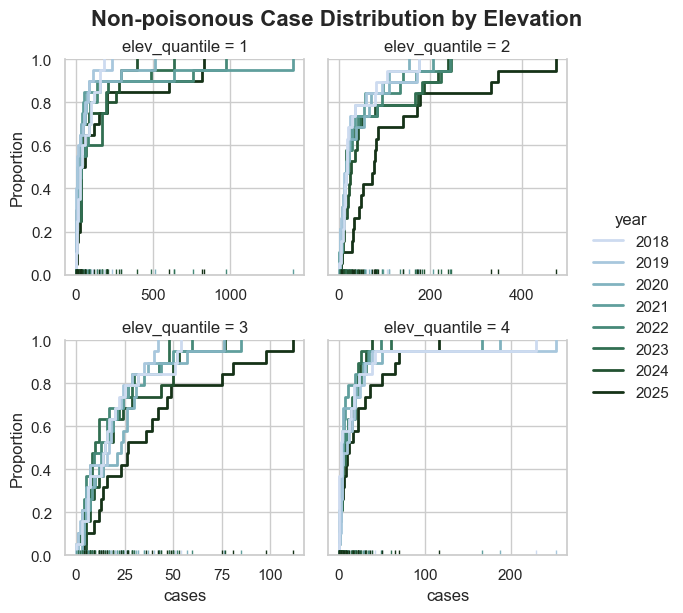

In [257]:
sns.set_theme(style="whitegrid")
pal = sns.cubehelix_palette(8, start=1.76)

ax = sns.displot(
    z,
    x="cases", col="elev_quantile", col_wrap = int(q/2), hue="year", 
    kind="ecdf", aspect=1, height = 3, linewidth=2, palette=pal, rug = True,
    facet_kws={"sharex": False}
)

ax.despine(right=False)
ax.figure.subplots_adjust(wspace=0.1)
plt.suptitle(category + ' Case Distribution by Elevation', fontsize=16, fontweight='bold', y=1.02)

plt.savefig(os.path.join("figures", category.lower() + '_summer_dist_by_elev.png'),
            dpi=150, 
            bbox_inches='tight')

plt.show()